In [1]:
import warnings
warnings.filterwarnings('ignore')

(Tutorial_Get_halogen_bonds)=
# get_halogen_bonds

*Calculating sparse directional halogen-bond observations.*

The experimental detector returns an independent `Interactions` analysis. Its descriptive method is `distance_two_angles`, with profile `smarts_donor_acceptor`. The ProLIF 2.2.2 geometric core adapts Auffinger et al. (2004); it is not the original paper's element-specific distance rule.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

See {func}`molsysmt.interactions.halogen_bonds.get_halogen_bonds` for arguments, errors and returned data.
:::

## Basic usage

Let's show how this function works with three controlled structures containing a halogen donor and carbonyl acceptor. The middle structure is deliberately outside the cutoff. These synthetic coordinates illustrate the criterion and do not represent an optimized molecular geometry.

In [2]:
import molsysmt as msm

In [3]:
from rdkit import Chem
import numpy as np
from molsysmt import pyunitwizard as puw

molsys = msm.convert(Chem.MolFromSmiles('CCl.C=O'), to_form='molsysmt.MolSys')
xyz = np.array([[-.15, 0, 0], [0, 0, 0], [.36, .12*np.sqrt(.75), 0], [.30, 0, 0]])
coordinates = np.repeat(xyz[None], 3, axis=0)
coordinates[1, [2, 3]] += [0, .5, 0]
molsys.structures.append(coordinates=puw.quantity(coordinates, 'nm'))

In [4]:
analysis = msm.interactions.halogen_bonds.get_halogen_bonds(molsys, pbc=False)
print(analysis.occurrence_structures)
print(analysis.participant_roles)
print(analysis.query(structure_indices=[1]).n_interactions)

[0 2]
('donor', 'halogen', 'acceptor', 'acceptor_reference')
0


## Understanding distance and orientation

For D–X···A–R, D is the atom bonded to halogen X, A is the acceptor and R is its reference neighbor. The inclusive defaults are X–A ≤ 0.35 nm, D–X–A between 130° and 180°, and X–A–R between 80° and 140°. Each eligible R defines a distinct relation. Undefined angles are skipped. Exact boundaries may differ from the angstrom reference through floating-point rounding; no geometric tolerance is added.

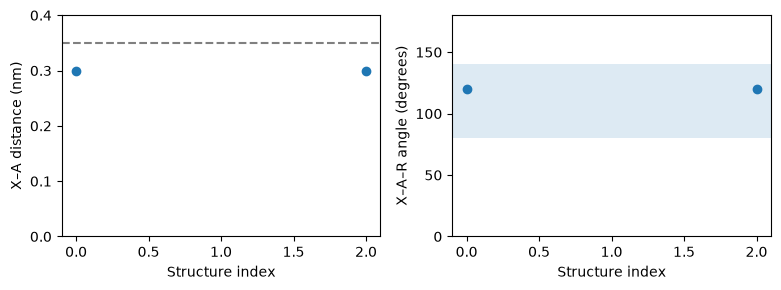

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].scatter(analysis.occurrence_structures, analysis.measurements['distance'])
axes[0].axhline(.35, color='gray', linestyle='--')
axes[0].set(xlabel='Structure index', ylabel='X–A distance (nm)', ylim=(0, .4))
axes[1].scatter(analysis.occurrence_structures, np.rad2deg(analysis.measurements['acceptor_angle']))
axes[1].axhspan(80, 140, alpha=.15)
axes[1].set(xlabel='Structure index', ylabel='X–A–R angle (degrees)', ylim=(0, 180))
fig.tight_layout()

## Selecting structures and participating atoms

Repeated structure indices are evaluated once. All four roles count: `internal` requires every participant, `incident` any participant, and `between` all participants inside two disjoint selections with at least one in each.

In [6]:
for mode, first, second in [('internal', [1, 3], None), ('incident', [2], None), ('between', [0, 1], [2, 3])]:
    scoped = msm.interactions.halogen_bonds.get_halogen_bonds(
        molsys, selection=first, selection_2=second, selection_mode=mode,
        structure_indices=[2, 0, 2], pbc=False)
    print(mode, scoped.n_interactions, scoped.evaluated_structure_indices)
print('Reference atom participates:', analysis.query(atom_indices=[2], mode='involving_selection').n_interactions)

internal 0 [0 2]
incident 2 [0 2]
between 2 [0 2]
Reference atom participates: 2


## Choosing units and output representation

Thresholds accept unitful quantities or length strings. Angular intervals contain two unitful values. Output measurement columns use explicit `nm` and `radians` regardless of the configured display-unit policy. Typed output carries all coverage, chemistry, evidence and producer metadata.

In [7]:
with puw.context(standard_units=['angstrom', 'degrees', 'ps', 'e']):
    typed = msm.interactions.halogen_bonds.get_halogen_bonds(
        molsys, distance_threshold='3.5 angstroms',
        donor_angle_range=puw.quantity([130, 180], 'degrees'),
        acceptor_angle_range=puw.quantity([80, 140], 'degrees'),
        output_type='molsysmt.InteractionsDict', pbc=False)
restored = msm.convert(typed, to_form='molsysmt.Interactions')
print(restored.measure_units)
assert restored.n_interactions == analysis.n_interactions

{'distance': 'nm', 'donor_angle': 'radians', 'acceptor_angle': 'radians', 'donor_halogen_distance': 'nm', 'acceptor_reference_distance': 'nm'}


## Reconstructing the periodic observation

With a valid box, consecutive D–X, X–A and A–R MIC vectors define one coherent observed chain anchored on D. A stored integer image adds `image_vector @ box` to its participant coordinate. This extension is not complete molecule unwrapping or ring closure.

In [8]:
periodic = msm.extract(molsys, structure_indices=[0])
box = np.eye(3)
lattice = np.array([[1, 0, 0], [0, 0, 0], [-1, 1, 0], [0, 1, 0]])
periodic.structures.coordinates = puw.quantity(coordinates[:1] + lattice @ box, 'nm')
periodic.structures.box = puw.quantity(box[None], 'nm')
observations = msm.interactions.halogen_bonds.get_halogen_bonds(periodic)
observed = puw.get_value(periodic.structures.coordinates, to_unit='nm')[0, observations.participant_atoms] + observations.image_vectors @ box
print(observations.image_vectors)
print('Observed X–A distance:', np.linalg.norm(observed[2] - observed[1]))

[[ 0  0  0]
 [ 1  0  0]
 [ 1 -1  0]
 [ 2 -1  0]]
Observed X–A distance: 0.30000000000000004


## Separating chemical interpretation from geometry

Use {func}`molsysmt.physchem.get_halogen_bond_sites` independently to inspect a halogenated ligand and peptide-fragment graph before proposing a geometry. Fluorine and positively charged acceptors are excluded by this profile. No attractive interaction energy or universal chemical accuracy is inferred.

In [9]:
sites = msm.physchem.get_halogen_bond_sites(Chem.MolFromSmiles('Clc1ccccc1.CC(=O)NCC(=O)O'))
print('Candidate donor pairs:', sites['donor_halogen_pairs'])
print('Candidate acceptor/reference pairs:', sites['acceptor_reference_pairs'])

Candidate donor pairs: [[1 0]]
Candidate acceptor/reference pairs: [[ 1  0]
 [ 1  2]
 [ 1  6]
 [ 2  3]
 [ 3  4]
 [ 4  5]
 [ 5  6]
 [ 9  8]
 [10  8]
 [10 11]
 [13 12]
 [14 12]]


## Working from files and recording the analysis

Attach explicitly under a name. Native and numeric-index H5MSM inputs deliver projected coordinate blocks through `heavy_mode="auto"` or `"force"`; rich file selections may require bounded eager loading. The complete chemical graph and accepted sparse output remain in memory. Match, candidate and result budgets raise explicitly; numerical estimates are not a process-RSS cap.

In [10]:
from tempfile import TemporaryDirectory
from pathlib import Path
with TemporaryDirectory() as directory:
    path = str(Path(directory) / 'halogens.h5msm')
    molsys.interactions = {**molsys.interactions, 'halogens': analysis}
    msm.convert(molsys, to_form=path)
    from_file = msm.interactions.halogen_bonds.get_halogen_bonds(path, structure_indices=[2, 0], pbc=False, heavy_mode='force')
    loaded = msm.convert(path, to_form='molsysmt.MolSys')
    assert loaded.interactions['halogens'].parameters == analysis.parameters
    print(from_file.evaluated_structure_indices)
print(analysis.software)
print([item['id'] for item in analysis.parameters['attribution']['items']])

[0 2]
{'molsysmt': '0.22.4+24.g42b487869', 'rdkit': '2025.09.5'}
['doi:10.1073/pnas.0407607101', 'doi:10.1186/s13321-021-00548-6', 'software:molsysmt:0.22.4+24.g42b487869', 'software:rdkit:2025.09.5']


The detached bibliography survives H5MSM and extraction. Optional application-owned Ackredit sessions credit completed calculations, including empty frames; reading saved results is not a new calculation. Water-mediated hydrogen bonds are a separate pending detector, not an automatic composition of these observations.

:::{seealso}
:class: dropdown

- {ref}`Tutorial_Convert` — form conversion with {func}`molsysmt.basic.convert`.
- {ref}`Tutorial_Get_halogen_bond_sites` — chemical recognition with {func}`molsysmt.physchem.get_halogen_bond_sites`.
- {ref}`Cookbook_Saving_halogen_bonds` — naming, saving and remapping observations.
:::